In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("real_estate_dataset.csv")

print('some beginning part of data: ',df.head())

print('data shape: ',df.shape)

some beginning part of data:     ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
0   1   143.635030             1              3           3        1967   
1   2   287.678577             1              2           1        1949   
2   3   232.998485             1              3           2        1923   
3   4   199.664621             5              2           2        1918   
4   5    89.004660             4              3           3        1999   

   Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center  \
0           1         1           48        8.297631            5.935734   
1           0         1           37        6.061466           10.827392   
2           1         0           14        2.911442            6.904599   
3           0         0           17        2.070949            8.284019   
4           1         0           34        1.523278           14.648277   

         Price  
0  602134.8167  
1  591425.1354  
2  464478.6

In [13]:
print('data info: ',df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  500 non-null    int64  
 1   Square_Feet         500 non-null    float64
 2   Num_Bedrooms        500 non-null    int64  
 3   Num_Bathrooms       500 non-null    int64  
 4   Num_Floors          500 non-null    int64  
 5   Year_Built          500 non-null    int64  
 6   Has_Garden          500 non-null    int64  
 7   Has_Pool            500 non-null    int64  
 8   Garage_Size         500 non-null    int64  
 9   Location_Score      500 non-null    float64
 10  Distance_to_Center  500 non-null    float64
 11  Price               500 non-null    float64
dtypes: float64(4), int64(8)
memory usage: 47.0 KB
data info:  None


In [16]:
print(df.describe())

               ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  \
count  500.000000   500.000000    500.000000     500.000000  500.000000   
mean   250.500000   174.640428      2.958000       1.976000    1.964000   
std    144.481833    74.672102      1.440968       0.820225    0.802491   
min      1.000000    51.265396      1.000000       1.000000    1.000000   
25%    125.750000   110.319923      2.000000       1.000000    1.000000   
50%    250.500000   178.290937      3.000000       2.000000    2.000000   
75%    375.250000   239.031220      4.000000       3.000000    3.000000   
max    500.000000   298.241199      5.000000       3.000000    3.000000   

        Year_Built  Has_Garden    Has_Pool  Garage_Size  Location_Score  \
count   500.000000  500.000000  500.000000   500.000000      500.000000   
mean   1957.604000    0.536000    0.492000    30.174000        5.164410   
std      35.491781    0.499202    0.500437    11.582575        2.853489   
min    1900.000000    0.

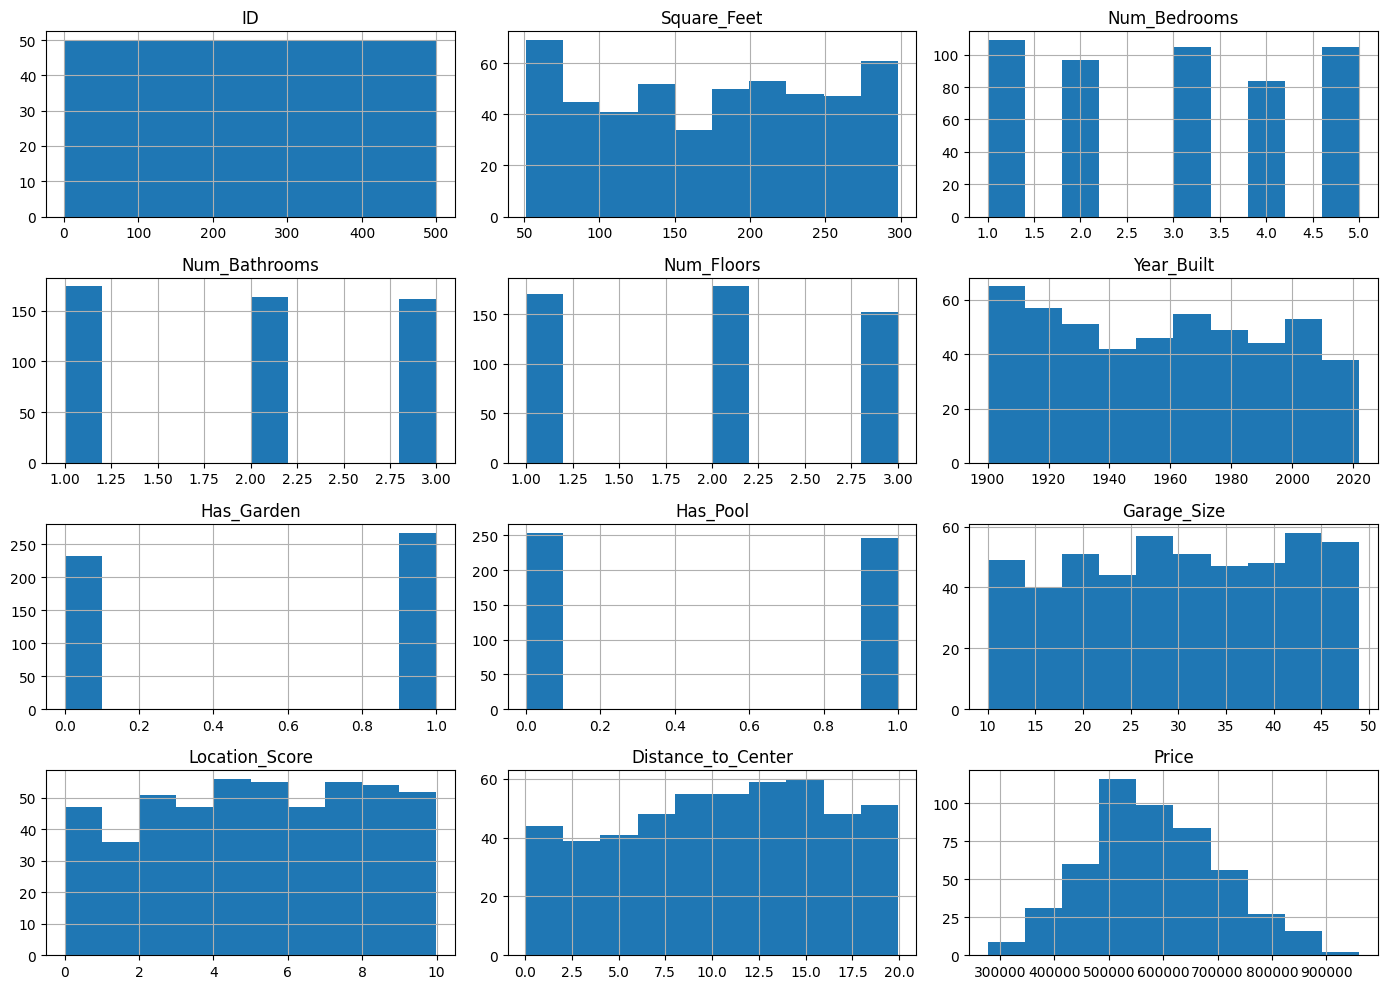

In [17]:
df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

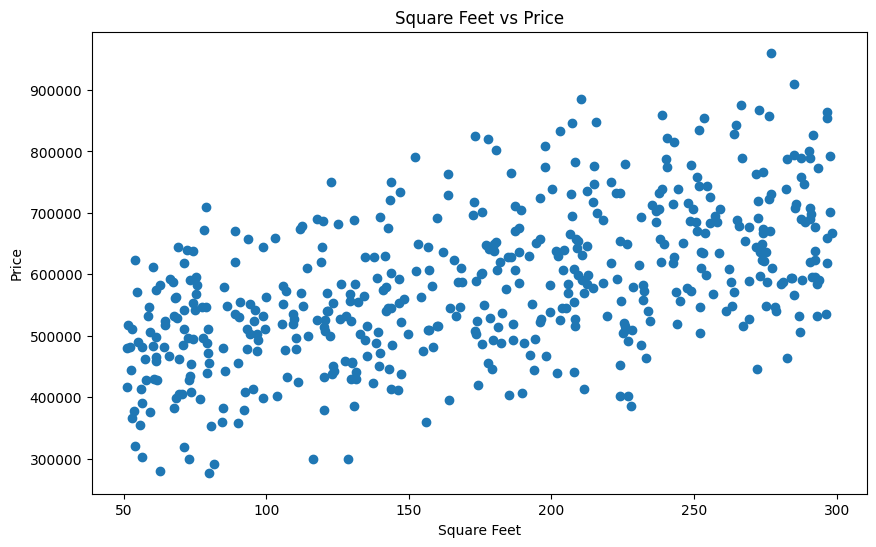

In [ ]:
# Question 2.b: Scatter plot of Square_Feet vs Price
plt.figure(figsize=(10,6))
plt.scatter(df["Square_Feet"], df["Price"])
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("Square Feet vs Price")
plt.show()

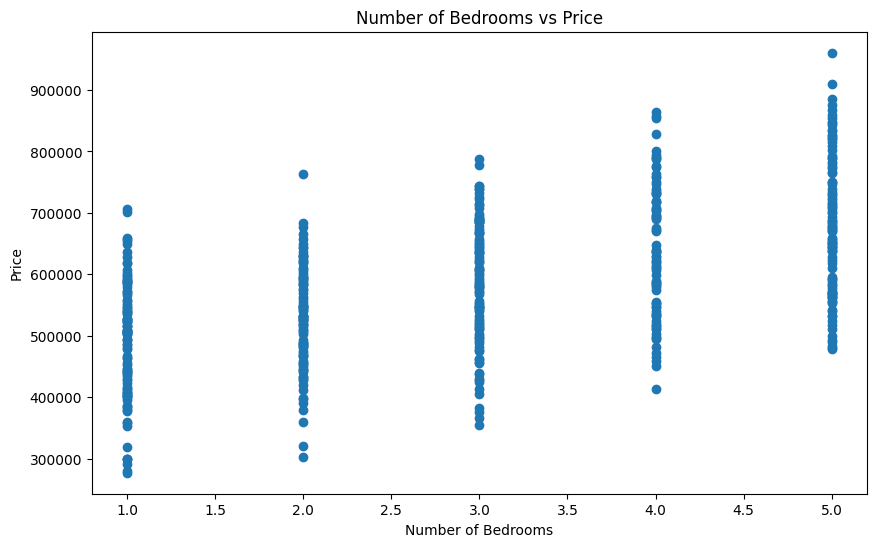

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(df["Num_Bedrooms"], df["Price"])
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")
plt.title("Number of Bedrooms vs Price")
plt.show()

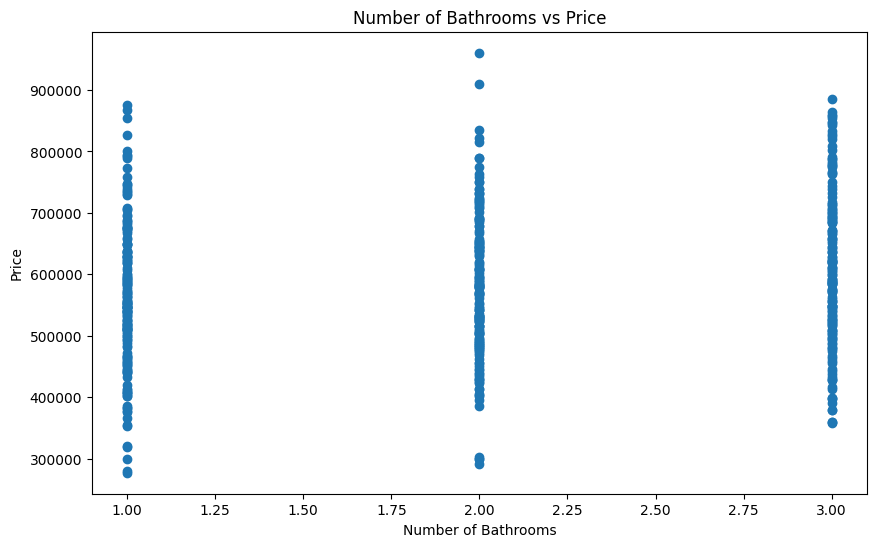

In [31]:
plt.figure(figsize=(10,6))
plt.scatter(df["Num_Bathrooms"], df["Price"])
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")
plt.title("Number of Bathrooms vs Price")
plt.show()

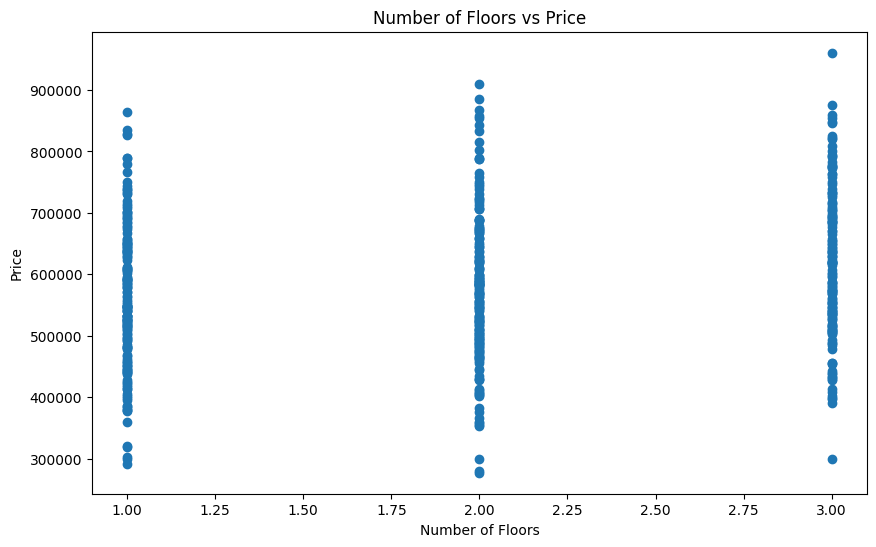

In [32]:
plt.figure(figsize=(10,6))
plt.scatter(df["Num_Floors"], df["Price"])
plt.xlabel("Number of Floors")
plt.ylabel("Price")
plt.title("Number of Floors vs Price")
plt.show()


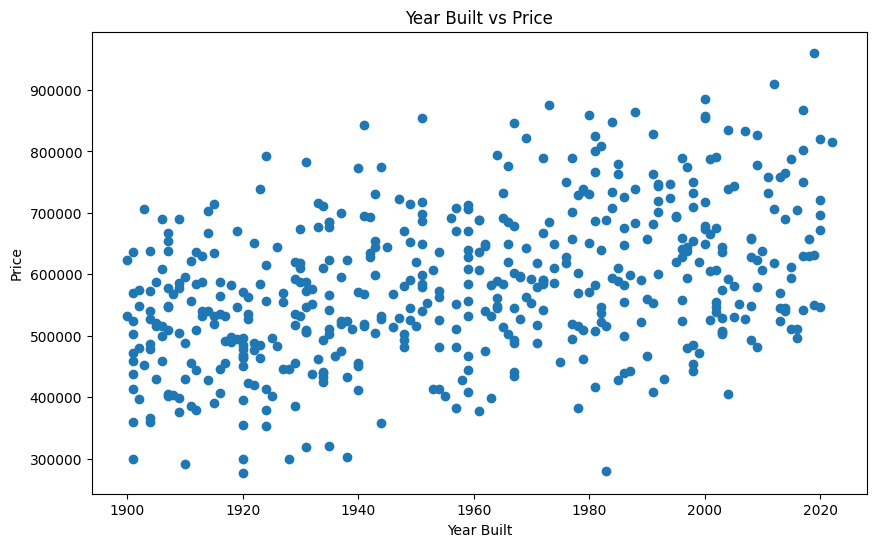

In [33]:
plt.figure(figsize=(10,6))
plt.scatter(df["Year_Built"], df["Price"])
plt.xlabel("Year Built")
plt.ylabel("Price")
plt.title("Year Built vs Price")
plt.show()

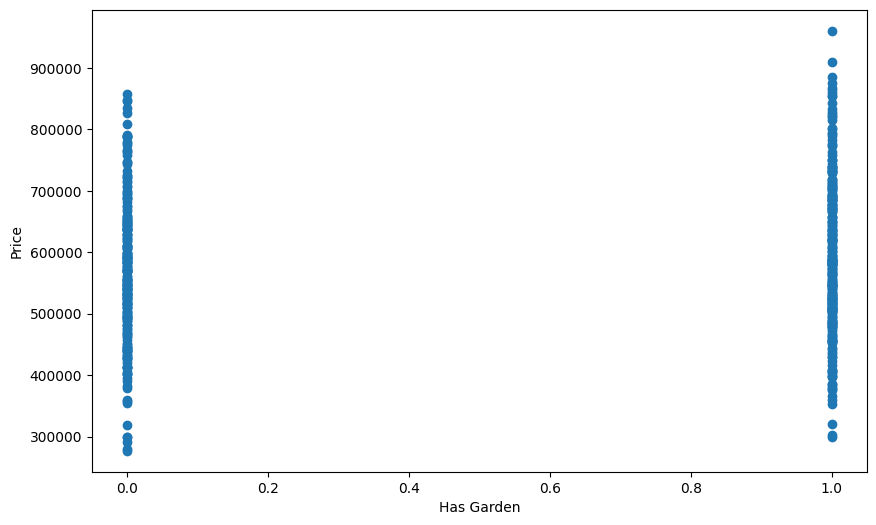

In [34]:
plt.figure(figsize=(10,6))
plt.scatter(df["Has_Garden"], df["Price"])
plt.xlabel("Has Garden")
plt.ylabel("Price")
plt.show()

In [39]:
# Question 3
# Normal equation: theta = (X^T * X)^(-1) * X^T * y
y = df["Price"].values
X = df.drop(columns=["ID","Price"]).values
# now adding the first column as 1,1,1,1... for the bias term
ones = np.ones((X.shape[0], 1))
X=np.hstack((ones, X))
theta = np.matmul(np.linalg.inv(np.matmul(np.transpose(X), X)), np.matmul(np.transpose(X), y))
theta

array([-2.89662923e+06,  1.01780336e+03,  5.06851880e+04,  2.99479954e+04,
        2.11340195e+04,  1.51824128e+03,  3.04555023e+04,  4.74152538e+04,
        1.13527772e+03,  4.80536342e+03, -1.94489819e+03])

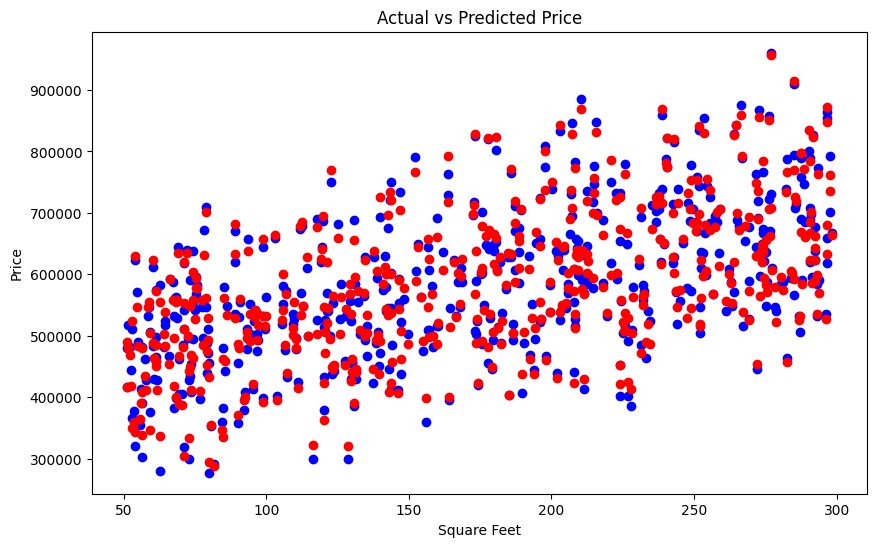

Mean Absolute Percentage Error: 2.7603099579680612 %


In [46]:
# lets plot the predicted vs actual price
y_pred = np.matmul(X, theta)
percent_error = np.abs((y - y_pred) / y) * 100
plt.figure(figsize=(10,6))
plt.scatter(df["Square_Feet"], y, color='blue', label="Actual Price")
plt.scatter(df["Square_Feet"], y_pred, color='red', label="Predicted Price")
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("Actual vs Predicted Price")
plt.show()
mape = np.mean(percent_error)
print("Mean Absolute Percentage Error:", mape, "%")

In [5]:
# Question 4: We will be atempting stochastic gradient descent without using normalzation
y = df["Price"].values.astype(float)
X_raw= df.drop(columns=["ID","Price"]).values.astype(float)
m, n = X_raw.shape  # m=500, n=10
X = np.c_[np.ones(m), X_raw] 

alpha = 0.01
epochs = 100
theta = np.zeros(X.shape[1])
loss_hist = []
theta1_hist = []
theta10_hist = []
for epoch in range(epochs):
    for i in range(m):
        xi = X[i]
        yi = y[i]
        err = np.dot(xi, theta) - yi
        theta = theta - alpha * err * xi
    preds = X @ theta
    loss = np.sum((preds - y)**2) / (2*m)
    loss_hist.append(loss)
    theta1_hist.append(theta[1])
    theta10_hist.append(theta[10])
print("Theta from SGD:", theta)

Theta from SGD: [nan nan nan nan nan nan nan nan nan nan nan]


Theta from SGD: [580370.03743114  75118.58890982  73106.7874379   23371.3201633
  16537.99838285  52491.98921087  17359.73187618  23387.80480013
  11302.61188741  13099.9578661  -10884.58463814]


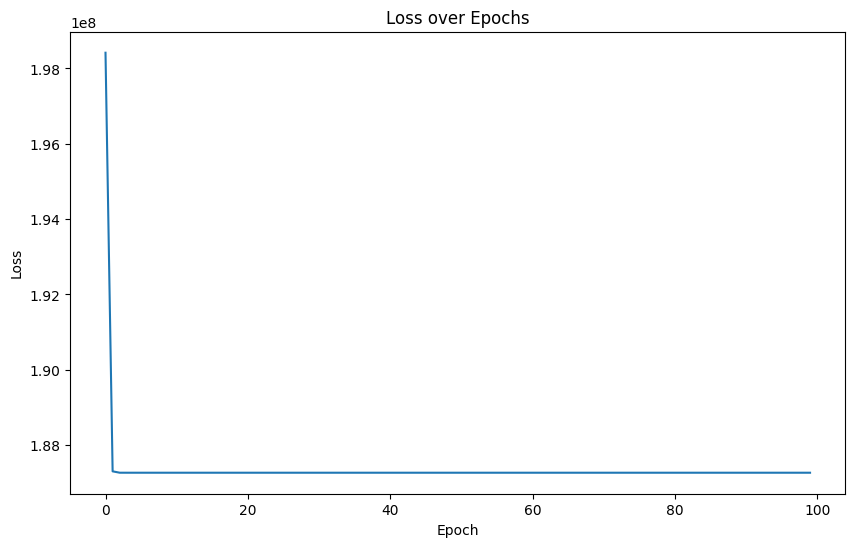

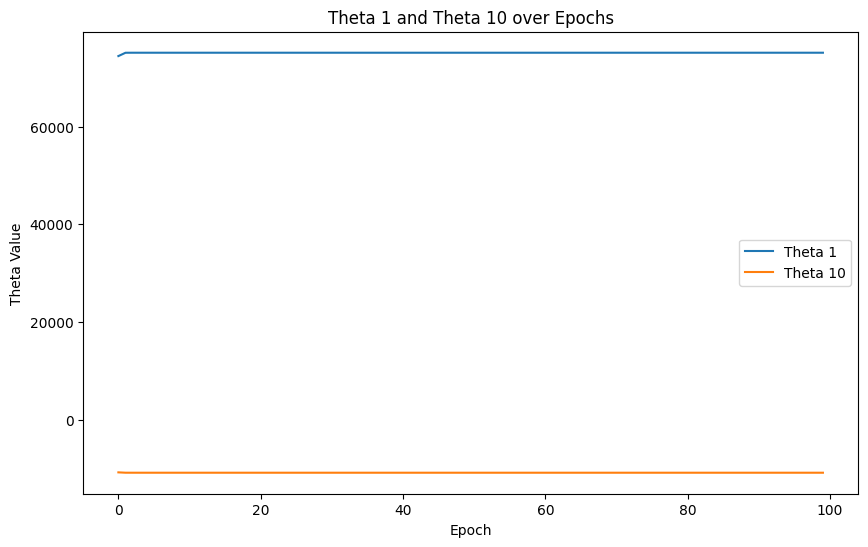

In [11]:
y = df["Price"].values.astype(float)
X_raw= df.drop(columns=["ID","Price"]).values.astype(float)

mu = X_raw.mean(axis=0)
sigma = X_raw.std(axis=0)
X_raw = (X_raw - mu) / sigma

m, n = X_raw.shape  # m=500, n=10
X = np.c_[np.ones(m), X_raw] 

alpha = 0.01
epochs = 100
theta = np.zeros(X.shape[1])
loss_hist = []
theta1_hist = []
theta10_hist = []
for epoch in range(epochs):
    for i in range(m):
        xi = X[i]
        yi = y[i]
        err = np.dot(xi, theta) - yi
        theta = theta - alpha * err * xi
    preds = X @ theta
    loss = np.sum((preds - y)**2) / (2*m)
    loss_hist.append(loss)
    theta1_hist.append(theta[1])
    theta10_hist.append(theta[10])
print("Theta from SGD:", theta)
plt.figure(figsize=(10,6))
plt.plot(loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.show()
plt.figure(figsize=(10,6))
plt.plot(theta1_hist, label="Theta 1")
plt.plot(theta10_hist, label="Theta 10")
plt.xlabel("Epoch")
plt.ylabel("Theta Value")
plt.title("Theta 1 and Theta 10 over Epochs")
plt.legend()
plt.show()


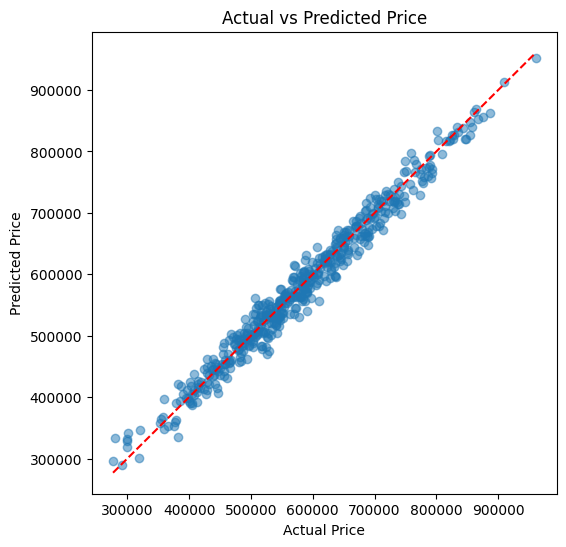

MAPE: 2.8046069673487586 %


In [12]:
y_pred = np.matmul(X, theta)
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()
mape = np.mean(np.abs((y - y_pred) / y)) * 100
print("MAPE:", mape, "%")